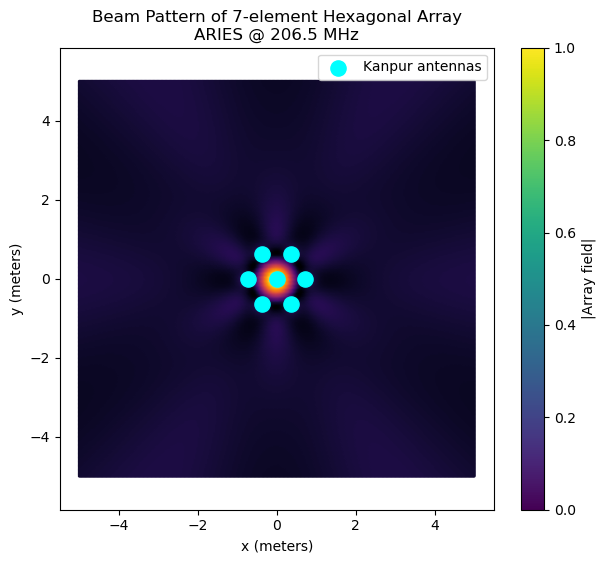

In [3]:
import numpy as np

c = 3e8
f = 206.5e6
lam = c / f          # 1.453 m
R = lam / 2          # 0.7265 m

tx_positions = np.array([
    [0, 0],                        # center
    [ R, 0],
    [ R/2,  np.sqrt(3)*R/2],
    [-R/2,  np.sqrt(3)*R/2],
    [-R, 0],
    [-R/2, -np.sqrt(3)*R/2],
    [ R/2, -np.sqrt(3)*R/2],
])
def calculate_gains(tx_positions, rx_positions, wavelength):
    """
    Complex received field from plane wave approximation.
    """
    k = 2 * np.pi / wavelength
    rx_signals = np.zeros(len(rx_positions), dtype=complex)

    for i, rx in enumerate(rx_positions):
        field = 0
        for tx in tx_positions:
            d = np.linalg.norm(rx - tx)
            field += np.exp(-1j * k * d)
        rx_signals[i] = field

    return rx_signals
def create_grid(*args):
    grid = np.array(np.meshgrid(*args))
    return grid.reshape((len(grid), -1)).T

rx_xs = np.linspace(-5, 5, 300)
rx_ys = np.linspace(-5, 5, 300)
rx_positions = create_grid(rx_xs, rx_ys)
import matplotlib.pyplot as plt

rx_signals = calculate_gains(tx_positions, rx_positions, lam)

plt.figure(figsize=(7,6))
plt.scatter(rx_positions[:,0], rx_positions[:,1],
            c=np.abs(rx_signals),
            cmap='inferno', s=2)

plt.scatter(tx_positions[:,0], tx_positions[:,1],
            c='cyan', s=120, label='Kanpur antennas')

plt.colorbar(label='|Array field|')
plt.xlabel('x (meters)')
plt.ylabel('y (meters)')
plt.title('Beam Pattern of 7-element Hexagonal Array\nARIES @ 206.5 MHz')
plt.axis('equal')
plt.legend()
plt.show()
